In [1]:
# Import Library
import os, re, json, joblib, warnings, mysql.connector
import pandas as pd, numpy as np
from collections import Counter
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings('ignore')

C:\Users\Rara\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Data (MySQL)
conn = mysql.connector.connect(host="127.0.0.1", user="root", password="", database="chatbot")
df = pd.read_sql("SELECT id, nama_ruangan, nama_gedung, kategori, fungsi_ruangan, navigasi, kata_kunci FROM data_ruangans ORDER BY id", conn)
conn.close()
nama = dict(zip(df['id'], df['nama_ruangan']))
print(f"[OK] {len(df)} ruangan dimuat.")

[OK] 138 ruangan dimuat.


In [3]:
# Slang & Stopwords
try:
    with open("python_chatbot/model_resource/slang.json", 'r', encoding='utf-8') as f:
        slang_dict = json.load(f)
except:
    slang_dict = {}

STOPWORDS = {
    "dimana", "lokasi", "cari", "arah", "rute", "cara", "ke", "posisi", "letak",
    "mana", "dimanakah", "temukan", "tunjukkan", "tolong", "bantu", "info",
    "rsj", "rs", "tampan", "rumah", "sakit", "di", "dari", "ada",
    "apa", "yang", "dan", "atau", "saya", "mau", "ingin", "ya", "sih", "saja"
}
PREFIXES = {"ruang", "ruangan", "kamar", "kantor", "klinik", "poli", "toilet", "mushola", "gedung", "instalasi"}
multi_slang = sorted([(k, v) for k, v in slang_dict.items() if ' ' in k], key=lambda x: len(x[0]), reverse=True)

In [4]:
# Preprocessing Helpers
def clean_text(teks, pakai_slang=True):
    if not teks: return ""
    teks = re.sub(r'[^a-z0-9\s]', ' ', str(teks).lower()).strip()
    if not pakai_slang: return " ".join(teks.split())
    for f, p in multi_slang:
        teks = re.sub(r'\b' + re.escape(f) + r'\b', p, teks)
    return " ".join(slang_dict.get(w, w) for w in teks.split())

def strip_pref(t):
    w = t.split()
    while w and w[0] in PREFIXES: w = w[1:]
    return " ".join(w)

def get_floor(t):
    for i, kws in enumerate([
        ("lantai 1", "lt 1", "lantai satu"),
        ("lantai 2", "lt 2", "lantai dua"),
        ("lantai 3", "lt 3", "lantai tiga")
    ], 1):
        if any(k in t.lower() for k in kws): return i
    return None

def rm_stop(t):
    return " ".join(w for w in t.split() if w not in STOPWORDS)

print(f"[OK] Slang: {len(slang_dict)} entri. Preprocessing siap.")

[OK] Slang: 451 entri. Preprocessing siap.


In [5]:
# Build Room Metadata
LIST_GEDUNG = [clean_text(g, False) for g in df['nama_gedung'].dropna().unique() if str(g).strip()]
meta = {}

for _, r in df.iterrows():
    rid = int(r['id'])
    rn, rg, rk = str(r['nama_ruangan'] or ''), str(r['nama_gedung'] or ''), str(r['kata_kunci'] or '')
    rkat, rfun, rnav = str(r['kategori'] or ''), str(r['fungsi_ruangan'] or ''), str(r['navigasi'] or '')
    nd, ns = clean_text(rn, False), clean_text(rn, True)
    kd, ks = clean_text(rk.replace(';', ' '), False), clean_text(rk.replace(';', ' '), True)
    
    kl = [k.strip() for k in rk.replace(';', ',').split(',') if len(k.strip()) > 1]
    nm_ns = rm_stop(ns)
    
    meta[rid] = {
        'nama': rn, 'gedung': rg, 'kategori': rkat, 'fungsi': rfun, 'kunci': rk, 'navigasi': rnav,
        'nm_ns': nm_ns, 'nm_nss': strip_pref(nm_ns),
        'nm_db_ns': rm_stop(nd), 'nm_db_nss': strip_pref(rm_stop(nd)),
        'bldg_cl': clean_text(rg), 'floor': get_floor(f"{rn} {rnav} {rk}"),
        'words': set(nd.split() + ns.split() + kd.split() + ks.split()),
        'kunci_all': [clean_text(k, False) for k in kl] + [clean_text(k, True) for k in kl],
        'r_text': f"{rn} {rnav} {rk}".lower(),
    }
print(f"[OK] Metadata {len(meta)} ruangan dibuat.")

[OK] Metadata 138 ruangan dibuat.


In [6]:
# S-BERT Indexing
os.environ.update({"HF_HUB_OFFLINE":"1", "TRANSFORMERS_OFFLINE":"1"})
embedder = SentenceTransformer("python_chatbot/model_resource/sbert_miniLM", device="cpu")
X_sem, sem_ids = [], []

for rid, m in meta.items():
    rn, rg, rkat, rk = m['nama'], m['gedung'], m['kategori'], m['kunci']
    nd, ns = clean_text(rn, False), clean_text(rn, True)
    
    X_sem.extend([nd, ns, clean_text(f"{rn} {rg} {rkat}", False)])
    sem_ids.extend([rid, rid, rid])
    
    for k in rk.replace(';', ',').split(','):
        kc = clean_text(k.strip(), False)
        if len(kc) > 2:
            X_sem.append(kc)
            sem_ids.append(rid)

sem_emb = embedder.encode(X_sem, show_progress_bar=False)
print(f"[OK] S-BERT: {len(sem_emb)} vektor diindeks.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8531.54it/s]


[OK] S-BERT: 2627 vektor diindeks.


In [7]:
# Hybrid Search (S-BERT + Fuzzy)
def hybrid_search(query, top_k=1):
    q_sl  = clean_text(query, True)
    q_raw = clean_text(query, False)
    q_ns  = rm_stop(q_sl) or q_sl
    q_nss = strip_pref(q_ns)
    q_tok = set(q_ns.split() + q_raw.split()) - STOPWORDS

    # S-BERT Similarity
    sem_sim = cosine_similarity(embedder.encode([q_ns], show_progress_bar=False), sem_emb)[0]
    sem_sc = {}
    for i, rid in enumerate(sem_ids):
        sem_sc[rid] = max(sem_sc.get(rid, 0.0), float(sem_sim[i]))

    floor_q = get_floor(q_sl)
    gedung_q = [g for g in LIST_GEDUNG if g and g in q_sl]

    final = {}
    for rid, m in meta.items():
        # Ensemble (S-BERT 70%, Fuzzy 30%)
        fz = len(q_tok & m['words']) / max(len(q_tok), 1)
        sc = 0.70 * sem_sc.get(rid, 0.0) + 0.30 * fz

        # Booster Nama
        if q_ns in (m['nm_ns'], m['nm_db_ns']) or q_nss in (m['nm_nss'], m['nm_db_nss']):
            sc += 1.80
        elif re.search(r'\b' + re.escape(m['nm_ns']) + r'\b', q_ns) or re.search(r'\b' + re.escape(q_ns) + r'\b', m['nm_ns']):
            sc += 0.40
        elif m['nm_ns'] in q_ns or q_ns in m['nm_ns']:
            sc += 0.20

        # Booster Kata Kunci (akumulasi semua keyword, max 2.5)
        kw_boost = 0.0
        for k in m['kunci_all']:
            if k in m['bldg_cl'] or m['bldg_cl'] in k: continue
            if k in (q_ns, q_sl):
                kw_boost = max(kw_boost, 1.50)
            elif re.search(r'\b' + re.escape(k) + r'\b', q_sl):
                kw_boost += min(0.30 * len(k.split()), 0.90)
            elif k in q_sl or q_sl in k:
                kw_boost += 0.15
        sc += min(kw_boost, 2.5)
        # Filter Lantai, Gedung, Arah
        if floor_q and m['floor']:
            sc += 0.40 if floor_q == m['floor'] else -1.00
        for g in gedung_q:
            sc += 0.40 if g in m['bldg_cl'] else -0.80
        for side in ('kiri', 'kanan'):
            if side in q_sl:
                opp = 'kanan' if side == 'kiri' else 'kiri'
                sc += 0.50 if side in m['r_text'] else (-0.50 if opp in m['r_text'] else 0)

        final[rid] = min(max(sc, 0.0), 3.0)

    ranked = sorted(final.items(), key=lambda x: x[1], reverse=True)
    return (ranked[0][0], float(ranked[0][1] / 3.0 * 100)) if top_k == 1 else ranked[:top_k]

print("[OK] Fungsi hybrid_search() siap.")

[OK] Fungsi hybrid_search() siap.


In [8]:
# Evaluasi Akurasi (Realistis: nama + semua keyword)
correct, total, failed = 0, 0, []
for _, r in df.iterrows():
    rid, rn, rkc = int(r['id']), str(r['nama_ruangan']), str(r['kata_kunci'] or '')
    queries = {f'dimana {rn}'} | {k.strip() for k in rkc.replace(';',',').split(',') if len(k.strip())>2}
    for q in queries:
        pid, sc = hybrid_search(q); total += 1
        if pid == rid: correct += 1
        else: failed.append({'q':q,'target':rn,'tid':rid,'pred':nama.get(pid,'?'),'pid':pid,'sc':sc})
print(f'Akurasi: {correct/total*100:.2f}% ({correct}/{total})')
if failed:
    print(f'\n{len(failed)} gagal:')
    for f in failed: print(f"  '{f['q']}' -> {f['target']}(ID{f['tid']}) | Got: {f['pred']}(ID{f['pid']}) {f['sc']:.1f}%")
else: print('SEMPURNA! 100% benar!')

Akurasi: 96.04% (2257/2350)

93 gagal:
  'rapat pimpinan rumah sakit' -> Ruang Rapat(ID1) | Got: Direktur(ID38) 91.0%
  'rapat pimpinan tertinggi rs' -> Ruang Rapat(ID1) | Got: Direktur(ID38) 89.7%
  'server data rumah sakit' -> SIMRS(ID9) | Got: Ruang Arsip(ID113) 79.2%
  'pengambilan obat bangsal inap' -> Farmasi Rawat Inap(ID12) | Got: Resepsionis Farmasi(ID70) 100.0%
  'tempat ambil obat pasien opname' -> Farmasi Rawat Inap(ID12) | Got: Resepsionis Farmasi(ID70) 100.0%
  'ambil obat pasien inap' -> Farmasi Rawat Inap(ID12) | Got: Resepsionis Farmasi(ID70) 100.0%
  'pengambilan obat rawat inap' -> Farmasi Rawat Inap(ID12) | Got: Resepsionis Farmasi(ID70) 100.0%
  'tempat ambil obat rawat inap' -> Farmasi Rawat Inap(ID12) | Got: Resepsionis Farmasi(ID70) 100.0%
  'tempat jenazah sebelum dipindah ke kamar jenazah' -> Transit Jenazah IGD(ID15) | Got: Kamar Jenazah(ID135) 100.0%
  'loket pendaftaran radiologi' -> Administrasi Radiologi IGD(ID21) | Got: Loket Pendaftaran(ID72) 92.3%
  'd

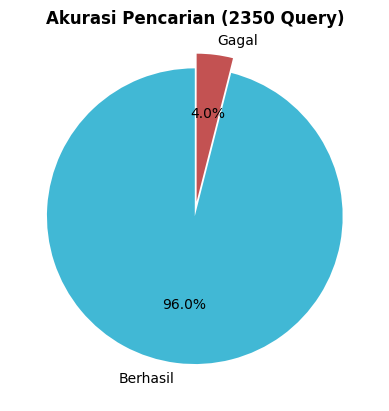

In [19]:
# VISUALISASI AKURASI PENCARIAN (PIE CHART)
import matplotlib.pyplot as plt

plt.pie([correct, total - correct], labels=['Berhasil', 'Gagal'], autopct='%1.1f%%', colors=['#41b8d5', '#c35252'], startangle=90, explode=(0, 0.1))

plt.title(f'Akurasi Pencarian ({total} Query)', fontweight='bold')
plt.show()


In [10]:
# Ekspor Model Pickle
joblib.dump({
    'embeddings': sem_emb, 'ids': sem_ids,
    'meta': {
        'nama': dict(zip(df['id'], df['nama_ruangan'])),
        'gedung': dict(zip(df['id'], df['nama_gedung'])),
        'kategori': dict(zip(df['id'], df['kategori'])),
        'kunci': {int(r['id']): f"{r['nama_ruangan']} {r['fungsi_ruangan']} {r['kategori']} {r['kata_kunci']}" for _, r in df.iterrows()}
    },
    'room_metadata': meta
}, 'python_chatbot/model_resource/modelDataRuangan.pkl')
print("[OK] modelDataRuangan.pkl berhasil diekspor!")

[OK] modelDataRuangan.pkl berhasil diekspor!
